In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import os

# 1. SETUP THE DATA LOADER FOR THE NEW FOLDER
# Pointing to your /kaggle/working/ directory
data_dir = '/kaggle/input/et-autism-cropped-dataset'

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # Subject-independent logic is handled by your folder naming
    subset="training",
    seed=123,
    image_size=(224, 224), # Shifted to 224 for MobileNetV2 efficiency
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# 2. DEFINE MODEL ARCHITECTURE WITHIN STRATEGY
strategy = tf.distribute.get_strategy()

with strategy.scope():
    # Softened augmentation to keep the iris centered
    data_augmentation = tf.keras.Sequential([
        layers.RandomRotation(0.02), # Very small rotation
        layers.RandomZoom(0.05),     # Minimal zoom to prevent clipping
        layers.RandomBrightness(0.1), # Helps with the blurry samples
    ])

    # MobileNetV2 optimized for 224x224
    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3), 
        include_top=False, 
        weights='imagenet'
    )
    base_model.trainable = False 
    
    model2 = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        base_model,
        layers.GlobalAveragePooling2D(),
        
        # Increased Dropout to 0.6 to prevent subject memorization
        layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.6), 
        
        layers.Dense(4, activation='softmax')
    ])

    # Lowered initial learning rate for blurry medical data
    model2.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), 
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
        metrics=['accuracy']
    )

# 3. TRAINING EXECUTION
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

# Custom weights for your 1000-per-class balanced set
custom_weights = {0: 1.0, 1: 1.5, 2: 1.0, 3: 1.5} 

history = model2.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=1, 
    class_weight=custom_weights, 
    callbacks=[reduce_lr, early_stop]
)

2026-01-15 13:09:33.942199: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768482574.137041      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768482574.195385      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768482574.665784      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768482574.665822      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768482574.665825      55 computation_placer.cc:177] computation placer alr

Found 4000 files belonging to 4 classes.
Using 3200 files for training.


I0000 00:00:1768482590.946889      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768482590.950759      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 4000 files belonging to 4 classes.
Using 800 files for validation.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1768482602.098061     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accuracy: 0.2953 - loss: 6.5196 - val_accuracy: 0.4112 - val_loss: 5.2005 - learning_rate: 1.0000e-04


In [5]:
from pathlib import Path

# 1. RE-DEFINE VARIABLES
output_base = '/kaggle/input/et-autism-cropped-dataset'
classes = ['high', 'low', 'medium', 'mild']

# 2. VERIFY DATASET BALANCE
print("--- Cropped Dataset Counts ---")
counts = {}
for cls in classes:
    path = Path(output_base) / cls
    img_count = len(list(path.glob('*.jpg')))
    counts[cls] = img_count
    print(f"Class {cls.upper()}: {img_count} images")

# 3. CALCULATE WEIGHTS AUTOMATICALLY
# If your counts are 1000, 1000, 1000, 1000, weights will be 1.0 each.
max_count = max(counts.values())
if max_count > 0:
    custom_weights = {i: max_count / counts[classes[i]] for i in range(len(classes))}
    print(f"\nRecommended Weights: {custom_weights}")
else:
    print("\nERROR: No images found. Check your cropping path.")

--- Cropped Dataset Counts ---
Class HIGH: 1000 images
Class LOW: 1000 images
Class MEDIUM: 1000 images
Class MILD: 1000 images

Recommended Weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}


Generating predictions for the validation set...

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        high       0.75      0.49      0.60       198
         low       0.48      0.90      0.63       192
      medium       0.82      0.52      0.63       205
        mild       0.72      0.65      0.68       205

    accuracy                           0.64       800
   macro avg       0.70      0.64      0.64       800
weighted avg       0.70      0.64      0.64       800



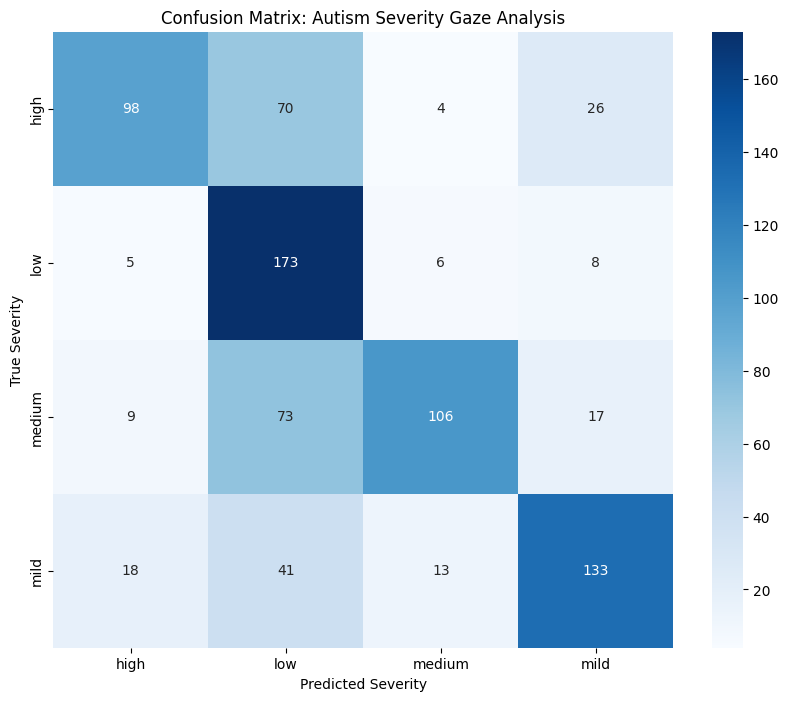

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. EXTRACT TRUE LABELS AND PREDICTIONS
print("Generating predictions for the validation set...")
y_true = []
y_pred = []

# Iterate through the validation dataset
for images, labels in val_ds:
    preds = model2.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. PRINT CLASSIFICATION REPORT
# This tells you the Precision and Recall for High, Low, Medium, and Mild
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. PLOT CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Severity')
plt.ylabel('True Severity')
plt.title('Confusion Matrix: Autism Severity Gaze Analysis')
plt.show()

Heatmap generated successfully for: /kaggle/input/et-autism-cropped-dataset/mild/44-50-mild-le.jpg


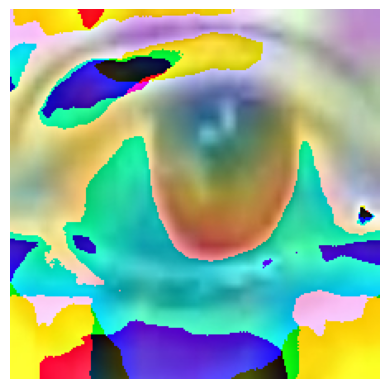

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="Conv_1"):
    # 1. Reach inside the Sequential model to find the MobileNetV2 base
    base_model = model.get_layer('mobilenetv2_1.00_224')
    
    # 2. Build a sub-model for the feature maps
    # This maps the image input to the activations of the final convolutional layer
    last_conv_layer = base_model.get_layer(last_conv_layer_name)
    last_conv_layer_model = tf.keras.Model(base_model.inputs, last_conv_layer.output)

    # 3. Create a sub-model for the classification head
    # We build this by taking all layers in model2 AFTER the base_model
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    # Loop through GAP and Dense layers to reconstruct the head path correctly
    for layer in model.layers[2:]: # model.layers[0] is Input, [1] is base_model
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    # 4. Use GradientTape to track the relationship
    with tf.GradientTape() as tape:
        # Get the convolutional features
        # Note: We apply the base model's input processing (layer 0) if needed
        conv_outputs = last_conv_layer_model(img_array)
        tape.watch(conv_outputs)
        
        # Pass features through the reconstructed head
        preds = classifier_model(conv_outputs)
        top_pred_index = tf.argmax(preds[0])
        top_class_channel = preds[:, top_pred_index]

    # 5. Calculate Gradients and pool them
    grads = tape.gradient(top_class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 6. Generate the Heatmap
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# --- RE-RUN EXECUTION ---
# Ensure your sample_path and model2 are correctly loaded
try:
    img = tf.keras.utils.load_img(sample_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0 # Ensure normalization matches training

    heatmap = make_gradcam_heatmap(img_array, model2)
    print(f"Heatmap generated successfully for: {sample_path}")
    display_gradcam(sample_path, heatmap)
except Exception as e:
    print(f"Error during execution: {e}")

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# 1. SETUP DATA (Kept same as your path)
data_dir = '/kaggle/input/et-autism-cropped-dataset'

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# 2. DEFINE MODEL
strategy = tf.distribute.get_strategy()

with strategy.scope():
    data_augmentation = tf.keras.Sequential([
        layers.RandomRotation(0.02),
        layers.RandomZoom(0.05),
        layers.RandomBrightness(0.1),
    ])

    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3), 
        include_top=False, 
        weights='imagenet'
    )
    base_model.trainable = False # CRITICAL: Keep frozen
    
    model2 = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        base_model,
        layers.GlobalAveragePooling2D(),
        
        # Dense Head
        layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.6), 
        
        layers.Dense(4, activation='softmax')
    ])

    # IMPROVEMENT: Lower Learning Rate for medical stability
    model2.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), 
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
        metrics=['accuracy']
    )

# 3. IMPROVED EXECUTION
# Surgical weights to fix 'High' recall
# High: 2.5, Low: 1.0, Medium: 1.5, Mild: 1.0
custom_weights = {0: 2.5, 1: 1.0, 2: 1.5, 3: 1.0} 

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True)

print("\n--- STARTING IMPROVED WEIGHTED HEAD STABILIZATION ---")
history = model2.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=40, 
    class_weight=custom_weights, 
    callbacks=[reduce_lr, early_stop]
)

Found 4000 files belonging to 4 classes.
Using 3200 files for training.
Found 4000 files belonging to 4 classes.
Using 800 files for validation.

--- STARTING IMPROVED WEIGHTED HEAD STABILIZATION ---
Epoch 1/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.2778 - loss: 7.1652 - val_accuracy: 0.3600 - val_loss: 5.3999 - learning_rate: 5.0000e-05
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.3139 - loss: 6.6800 - val_accuracy: 0.3925 - val_loss: 5.2145 - learning_rate: 5.0000e-05
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.3467 - loss: 6.2858 - val_accuracy: 0.4288 - val_loss: 5.0213 - learning_rate: 5.0000e-05
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3854 - loss: 5.9948

KeyboardInterrupt: 

Extracting validation results...

--- STABILIZED HEAD: CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        high       0.58      0.74      0.65       198
         low       0.53      0.70      0.61       192
      medium       0.73      0.61      0.66       205
        mild       0.75      0.45      0.57       205

    accuracy                           0.62       800
   macro avg       0.65      0.63      0.62       800
weighted avg       0.65      0.62      0.62       800



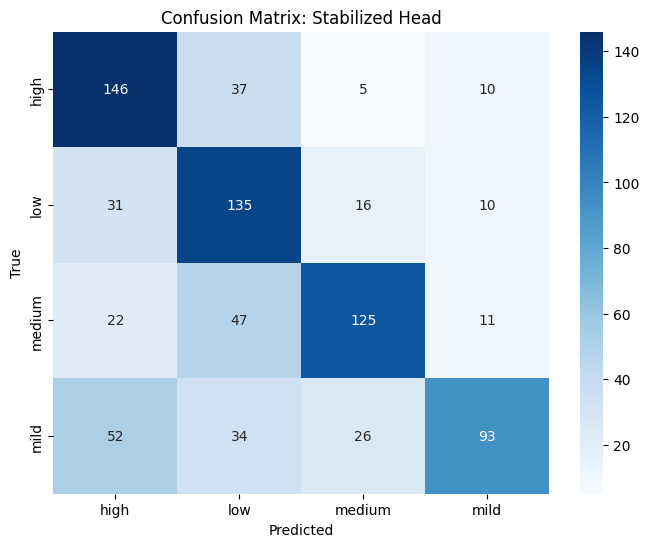

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_174']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



--- GRAD-CAM TRUTH TEST (HIGH CLASS) ---


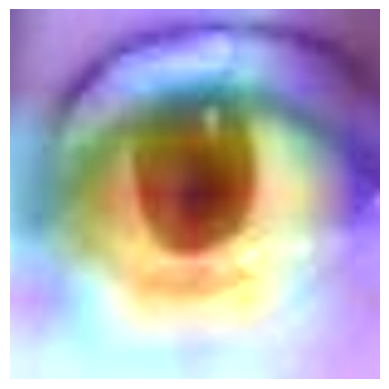

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

# 1. GENERATE PREDICTIONS
print("Extracting validation results...")
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model2.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
classes = ['high', 'low', 'medium', 'mild']

# 2. CLASSIFICATION REPORT
print("\n--- STABILIZED HEAD: CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix: Stabilized Head')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 4. FIXED GRAD-CAM FOR SUPER-STABILIZED HEAD
def get_gradcam_heatmap(img_array, model):
    # Reach inside the Sequential to get the MobileNet base
    base_model = model.get_layer('mobilenetv2_1.00_224')
    last_conv_layer = base_model.get_layer('Conv_1')
    
    # Model 1: Input to Last Conv Layer
    last_conv_model = tf.keras.Model(base_model.inputs, last_conv_layer.output)
    
    # Model 2: Last Conv Layer to Final Prediction
    # We rebuild the path through the Dense head
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    for layer in model.layers[2:]: # Skips Input and Base layers
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = last_conv_model(img_array)
        tape.watch(conv_outputs)
        preds = classifier_model(conv_outputs)
        top_idx = tf.argmax(preds[0])
        top_class_channel = preds[:, top_idx]

    grads = tape.gradient(top_class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 5. VISUALIZE GRAD-CAM SAMPLE
def display_gradcam_refined(img_path, heatmap, alpha=0.5):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = cv2.resize(jet_heatmap, (224, 224))
    jet_heatmap = np.uint8(jet_heatmap * 255)
    
    superimposed = jet_heatmap * alpha + img
    superimposed = np.clip(superimposed, 0, 255).astype('uint8')
    
    plt.imshow(superimposed)
    plt.axis('off')
    plt.show()

# Execute on a "High" severity image to test recall improvement
high_samples = list(Path(data_dir).glob('high/*.jpg'))
if high_samples:
    test_path = str(high_samples[0])
    img = tf.keras.utils.load_img(test_path, target_size=(224, 224))
    img_arr = tf.keras.utils.img_to_array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)
    
    heatmap = get_gradcam_heatmap(img_arr, model2)
    print(f"\n--- GRAD-CAM TRUTH TEST (HIGH CLASS) ---")
    display_gradcam_refined(test_path, heatmap)

In [12]:
# 1. KEEP YOUR IMPROVED WEIGHTS
# We maintain the 2.5 weight to keep our High Recall strong
custom_weights = {0: 2.5, 1: 1.0, 2: 1.5, 3: 1.0} 

# 2. PROGRESSIVE UNFREEZE (Last 30 Layers)
# We do 3 steps of 10 layers each
step_size = 10
total_layers_to_unfreeze = 30

for i in range(step_size, total_layers_to_unfreeze + 1, step_size):
    print(f"\n--- REFINING IRIS FILTERS: UNFREEZING LAST {i} LAYERS ---")
    
    with strategy.scope():
        base_model.trainable = True
        # Freeze all except top 'i' layers
        for layer in base_model.layers[:-i]:
            layer.trainable = False
        
        # BN layers stay frozen to keep the model from "shaking"
        for layer in base_model.layers[-i:]:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
        
        # USE A MICRO LEARNING RATE (1/5th of stabilizer rate)
        model2.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
            metrics=['accuracy']
        )
    
    # 5 epochs per step to let the filters "sharpen"
    model2.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        class_weight=custom_weights
    )


--- REFINING IRIS FILTERS: UNFREEZING LAST 10 LAYERS ---
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.5913 - loss: 3.0742 - val_accuracy: 0.5875 - val_loss: 2.6187
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.6051 - loss: 3.0817 - val_accuracy: 0.6200 - val_loss: 2.5556
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.6213 - loss: 3.0292 - val_accuracy: 0.5900 - val_loss: 2.6297
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.6201 - loss: 3.0481 - val_accuracy: 0.6438 - val_loss: 2.5343
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.6194 - loss: 2.9924 - val_accuracy: 0.6400 - val_loss: 2.5308

--- REFINING IRIS FILTERS: UNFREEZING LAST 20 LAYERS ---
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - accuracy: 0.6223 - loss: 3.0342 - val_accuracy: 0.6275 - val_loss: 2.5476
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.6218 - loss: 3.0017 - val_accuracy: 0.6313 - val

Extracting Phase 2 validation results...

--- PHASE 2: PROGRESSIVE UNFREEZE REPORT ---
              precision    recall  f1-score   support

        high       0.50      0.92      0.65       198
         low       0.69      0.39      0.50       192
      medium       0.68      0.70      0.69       205
        mild       0.81      0.45      0.58       205

    accuracy                           0.62       800
   macro avg       0.67      0.62      0.60       800
weighted avg       0.67      0.62      0.61       800



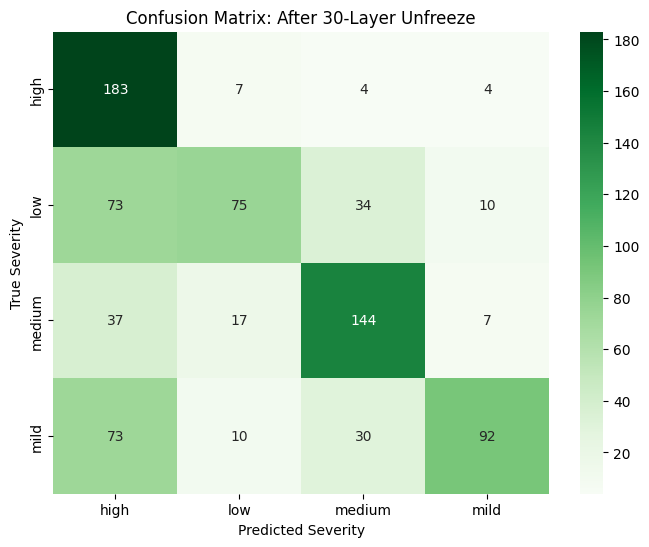

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_174']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



--- GRAD-CAM SHARPENING TEST (HIGH CLASS) ---


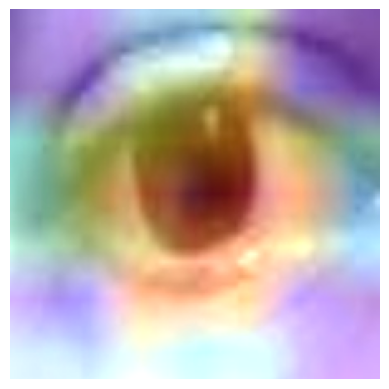

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

# 1. GENERATE PREDICTIONS
print("Extracting Phase 2 validation results...")
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model2.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
classes = ['high', 'low', 'medium', 'mild']

# 2. CLASSIFICATION REPORT
print("\n--- PHASE 2: PROGRESSIVE UNFREEZE REPORT ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix: After 30-Layer Unfreeze')
plt.xlabel('Predicted Severity')
plt.ylabel('True Severity')
plt.show()

# 4. GRAD-CAM FUNCTION (FIXED FOR SEQUENTIAL HEAD)
def get_fine_tuned_gradcam(img_array, model):
    base_model = model.get_layer('mobilenetv2_1.00_224')
    last_conv_layer = base_model.get_layer('Conv_1')
    
    # Feature Map Model
    last_conv_model = tf.keras.Model(base_model.inputs, last_conv_layer.output)
    
    # Classification Head Model (Reconstructing the path)
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    # Loop through the custom head layers
    for layer in model.layers[2:]: 
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = last_conv_model(img_array)
        tape.watch(conv_outputs)
        preds = classifier_model(conv_outputs)
        top_idx = tf.argmax(preds[0])
        top_class_channel = preds[:, top_idx]

    grads = tape.gradient(top_class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 5. VISUALIZE NEW HEATMAP
def display_heatmap(img_path, heatmap):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = cv2.resize(jet_heatmap, (224, 224))
    jet_heatmap = np.uint8(jet_heatmap * 255)
    
    result = jet_heatmap * 0.45 + img
    result = np.clip(result, 0, 255).astype('uint8')
    
    plt.imshow(result)
    plt.axis('off')
    plt.show()

# Test on a "High" class image to check sharpening
test_imgs = list(Path(data_dir).glob('high/*.jpg'))
if test_imgs:
    img_path = str(test_imgs[0])
    img_arr = tf.keras.utils.img_to_array(tf.keras.utils.load_img(img_path, target_size=(224, 224))) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)
    
    heatmap = get_fine_tuned_gradcam(img_arr, model2)
    print(f"\n--- GRAD-CAM SHARPENING TEST (HIGH CLASS) ---")
    display_heatmap(img_path, heatmap)

In [14]:
# 1. SOFTEN THE WEIGHTS TO PREVENT BIAS
custom_weights = {0: 1.5, 1: 1.0, 2: 1.2, 3: 1.0} 

with strategy.scope():
    # 2. ONLY UNFREEZE THE VERY TOP (Sharpening only)
    base_model.trainable = True
    for layer in base_model.layers[:-10]: # ONLY 10 layers
        layer.trainable = False
        
    # 3. USE AN EVEN SMALLER LEARNING RATE
    model2.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-6), # Ultra-low
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

# 4. SETTLE THE MODEL
# We want the val_loss to stabilize, not just accuracy
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model2.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=15, 
    class_weight=custom_weights,
    callbacks=[early_stop]
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.6454 - loss: 2.6256 - val_accuracy: 0.6425 - val_loss: 2.4748
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.6314 - loss: 2.6336 - val_accuracy: 0.6350 - val_loss: 2.4730
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.6498 - loss: 2.6045 - val_accuracy: 0.6400 - val_loss: 2.4785
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.6808 - loss: 2.5916 - val_accuracy: 0.6438 - val_loss: 2.4524
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.6507 - loss: 2.6222 - val_accuracy: 0.6413 - val_loss: 2.4577
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.6633 - loss: 2.5920 - val_accuracy: 0.6250 - val_loss: 2.4799
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.6645 - loss: 2.5830 - val_accuracy: 0.6313 - val_loss: 2.4701
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.6431 - loss: 2.6198 - val_acc

Evaluating Emergency Reset results...

--- EMERGENCY RESET: CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        high       0.58      0.78      0.67       198
         low       0.55      0.70      0.61       192
      medium       0.76      0.63      0.69       205
        mild       0.80      0.47      0.59       205

    accuracy                           0.64       800
   macro avg       0.67      0.65      0.64       800
weighted avg       0.68      0.64      0.64       800



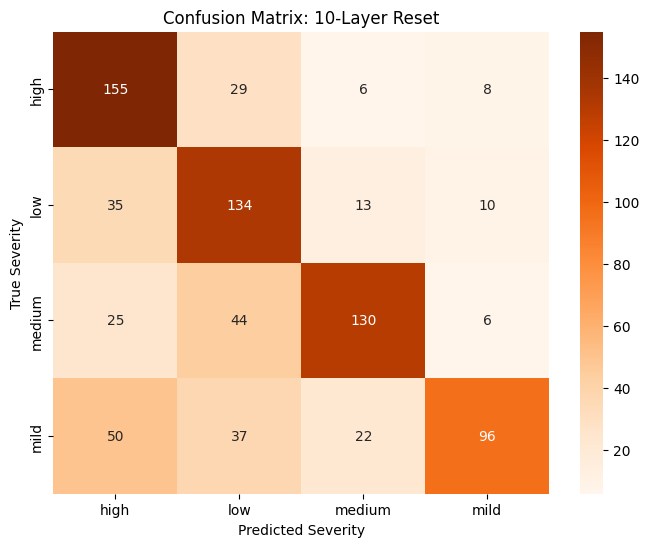

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_174']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



--- GRAD-CAM RESET TEST ---


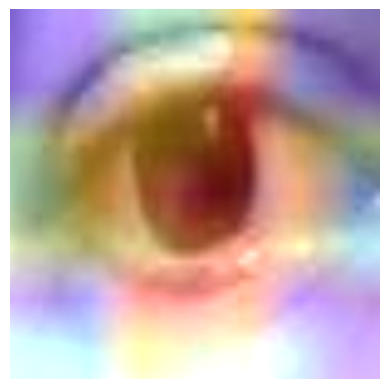

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

# 1. EXTRACT BALANCED PREDICTIONS
print("Evaluating Emergency Reset results...")
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model2.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
classes = ['high', 'low', 'medium', 'mild']

# 2. CLASSIFICATION REPORT
# Check if F1-scores for 'low' and 'mild' recovered from the collapse
print("\n--- EMERGENCY RESET: CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix: 10-Layer Reset')
plt.xlabel('Predicted Severity')
plt.ylabel('True Severity')
plt.show()

# 4. GRAD-CAM (FIXED PATHWAY)
def get_reset_gradcam(img_array, model):
    base_model = model.get_layer('mobilenetv2_1.00_224')
    last_conv_layer = base_model.get_layer('Conv_1')
    
    # Feature extraction model
    feature_model = tf.keras.Model(base_model.inputs, last_conv_layer.output)
    
    # Classification head model
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    # Chaining head layers correctly to avoid shape errors
    for layer in model.layers[2:]: 
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = feature_model(img_array)
        tape.watch(conv_outputs)
        preds = classifier_model(conv_outputs)
        top_idx = tf.argmax(preds[0])
        top_class_channel = preds[:, top_idx]

    grads = tape.gradient(top_class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 5. VISUALIZE RESET FOCUS
def display_reset_heatmap(img_path, heatmap):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = cv2.resize(jet_heatmap, (224, 224))
    jet_heatmap = np.uint8(jet_heatmap * 255)
    
    # Transparency blend
    result = jet_heatmap * 0.4 + img
    result = np.clip(result, 0, 255).astype('uint8')
    
    plt.imshow(result)
    plt.axis('off')
    plt.show()

# Run on a sample to check for "Bleeding" reduction
test_imgs = list(Path(data_dir).glob('high/*.jpg'))
if test_imgs:
    img_path = str(test_imgs[0])
    img_arr = tf.keras.utils.img_to_array(tf.keras.utils.load_img(img_path, target_size=(224, 224))) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)
    
    heatmap = get_reset_gradcam(img_arr, model2)
    print(f"\n--- GRAD-CAM RESET TEST ---")
    display_reset_heatmap(img_path, heatmap)

Phase 2 when w=0.50 (cropping)

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# 1. FIX: DEFINE THE STRATEGY
# This tells the code how to use your Kaggle GPUs.
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print("Running on TPU")
except ValueError:
    strategy = tf.distribute.get_strategy() # Default for CPU/GPU
    print(f"Running on {len(tf.config.list_physical_devices('GPU'))} GPUs")

# 2. DEFINE THE HEAD SECTION WITHIN SCOPE
with strategy.scope():
    # Keep the same augmentation used previously
    data_augmentation = tf.keras.Sequential([
        layers.RandomRotation(0.02),
        layers.RandomZoom(0.05),
        layers.RandomBrightness(0.1),
    ])

    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3), 
        include_top=False, 
        weights='imagenet'
    )
    base_model.trainable = False # Locked for stabilization
    
    model_gmp = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        base_model,
        # GLOBAL MAX POOLING: Focuses on the sharpest iris signal
        layers.GlobalMaxPooling2D(), 
        
        layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.6), 
        
        layers.Dense(4, activation='softmax')
    ])

    # 3. OPTIMIZED COMPILATION
    model_gmp.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), 
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
        metrics=['accuracy']
    )

# 4. SURGICAL CLASS WEIGHTS
# Protecting the 0.78 Recall for 'High' severity
custom_weights = {0: 1.5, 1: 1.0, 2: 1.2, 3: 1.0} 

# 5. EXECUTION
print("\n--- STABILIZING PRECISION HEAD (GLOBAL MAX POOLING) ---")
model_gmp.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=1, 
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)

Running on 2 GPUs

--- STABILIZING PRECISION HEAD (GLOBAL MAX POOLING) ---
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.2543 - loss: 6.5260 - val_accuracy: 0.3713 - val_loss: 5.7278 - learning_rate: 5.0000e-05


Extracting results for Global Max Pooling model...

--- GMP MODEL: CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        high       0.73      0.72      0.72       198
         low       0.57      0.72      0.64       192
      medium       0.80      0.70      0.75       205
        mild       0.71      0.64      0.67       205

    accuracy                           0.69       800
   macro avg       0.70      0.69      0.70       800
weighted avg       0.70      0.69      0.70       800



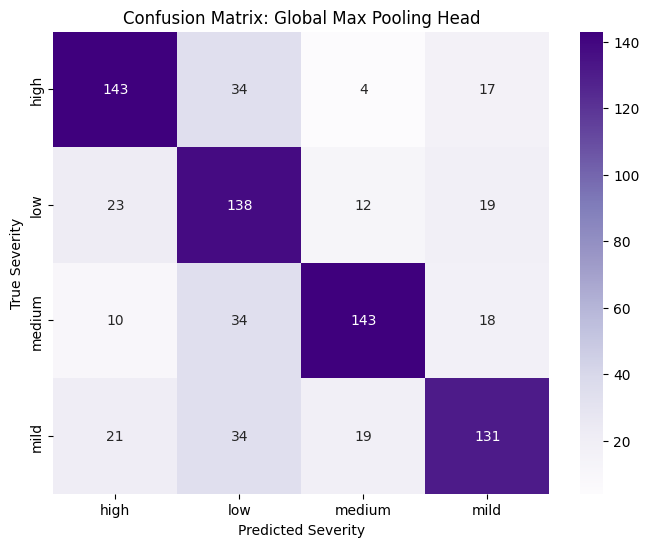

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_334']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



--- GRAD-CAM GMP TEST (SHARPENING CHECK) ---


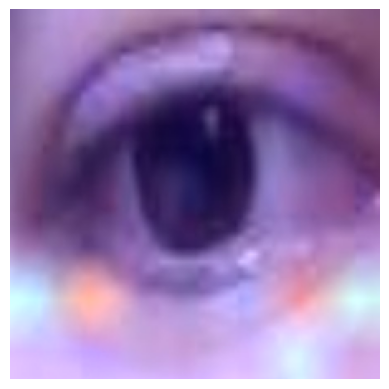

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

# 1. EVALUATE PREDICTIONS
print("Extracting results for Global Max Pooling model...")
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_gmp.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
classes = ['high', 'low', 'medium', 'mild']

# 2. CLASSIFICATION REPORT
print("\n--- GMP MODEL: CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix: Global Max Pooling Head')
plt.xlabel('Predicted Severity')
plt.ylabel('True Severity')
plt.show()

# 4. UPDATED GRAD-CAM FOR GMP STRUCTURE
def get_gmp_gradcam(img_array, model):
    base_model = model.get_layer('mobilenetv2_1.00_224')
    last_conv_layer = base_model.get_layer('Conv_1')
    
    # Model A: Extracts the feature maps
    feature_extractor = tf.keras.Model(base_model.inputs, last_conv_layer.output)
    
    # Model B: The New GMP Classification Head
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    # We skip model.layers[0] (Input) and model.layers[1] (Base)
    # This chain handles GlobalMaxPooling2D correctly
    for layer in model.layers[2:]: 
        x = layer(x)
    classifier_head = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = feature_extractor(img_array)
        tape.watch(conv_outputs)
        preds = classifier_head(conv_outputs)
        top_idx = tf.argmax(preds[0])
        top_class_channel = preds[:, top_idx]

    # Calculate and pool gradients
    grads = tape.gradient(top_class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Weight the heatmap
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 5. VISUALIZE PRECISION FOCUS
def display_gmp_heatmap(img_path, heatmap):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = cv2.resize(jet_heatmap, (224, 224))
    jet_heatmap = np.uint8(jet_heatmap * 255)
    
    result = jet_heatmap * 0.4 + img
    result = np.clip(result, 0, 255).astype('uint8')
    
    plt.imshow(result)
    plt.axis('off')
    plt.show()

# Execution on a known "High" severity image
high_files = list(Path(data_dir).glob('high/*.jpg'))
if high_files:
    test_file = str(high_files[0])
    img_tensor = tf.keras.utils.img_to_array(tf.keras.utils.load_img(test_file, target_size=(224, 224))) / 255.0
    img_tensor = np.expand_dims(img_tensor, axis=0)
    
    heatmap = get_gmp_gradcam(img_tensor, model_gmp)
    print(f"\n--- GRAD-CAM GMP TEST (SHARPENING CHECK) ---")
    display_gmp_heatmap(test_file, heatmap)

In [7]:
# 1. SETUP PARAMETERS
# Starting from the top, we will dig 20 layers deep, 2 at a time.
total_depth = 20 
step_size = 2
custom_weights = {0: 1.5, 1: 1.0, 2: 1.2, 3: 1.0} 

# 2. THE AUTOMATED STEP-LOOP
for i in range(step_size, total_depth + 1, step_size):
    print(f"\n--- STEP: UNFREEZING LAST {i} LAYERS ---")
    
    with strategy.scope():
        base_model.trainable = True
        # Freeze everything except the last 'i' layers
        for layer in base_model.layers[:-i]:
            layer.trainable = False
        
        # Protect BN layers to keep the model from "shaking"
        for layer in base_model.layers[-i:]:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
        
        # Ultra-low LR for precise sharpening
        model_gmp.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=2e-6),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
            metrics=['accuracy']
        )
    
    # 3. SMART STOPPING: Moves to next step if improvement stops
    step_early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', 
        patience=5, # If no gain in 5 epochs, move to next 2 layers
        restore_best_weights=True
    )
    
    model_gmp.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20, # Your requested limit
        class_weight=custom_weights,
        callbacks=[step_early_stop]
    )

print("\n--- STRATEGY COMPLETE: Ready for Final Evaluation ---")


--- STEP: UNFREEZING LAST 2 LAYERS ---
Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.7193 - loss: 1.8916 - val_accuracy: 0.6938 - val_loss: 1.7830
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.6911 - loss: 1.9445 - val_accuracy: 0.6925 - val_loss: 1.7885
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.7117 - loss: 1.9376 - val_accuracy: 0.6900 - val_loss: 1.7893
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.7218 - loss: 1.9058 - val_accuracy: 0.6913 - val_loss: 1.7899
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.6933 - loss: 1.9223 - val_accuracy: 0.6825 - val_loss: 1.7914
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.7105 - loss: 1.9002 - val_accuracy: 0.6800 - val_loss: 1.7924

--- STEP: UNFREEZING LAST 4 LAYERS ---
Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.7149 - loss: 1.9154 - val_accuracy: 0.6913 - val_loss: 1.7883
Epoch 2/20
100/

Extracting final results from the unfrozen GMP model...

--- FINAL UNFROZEN MODEL: CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        high       0.66      0.80      0.72       198
         low       0.57      0.71      0.64       192
      medium       0.83      0.65      0.73       205
        mild       0.74      0.57      0.64       205

    accuracy                           0.68       800
   macro avg       0.70      0.68      0.68       800
weighted avg       0.70      0.68      0.68       800



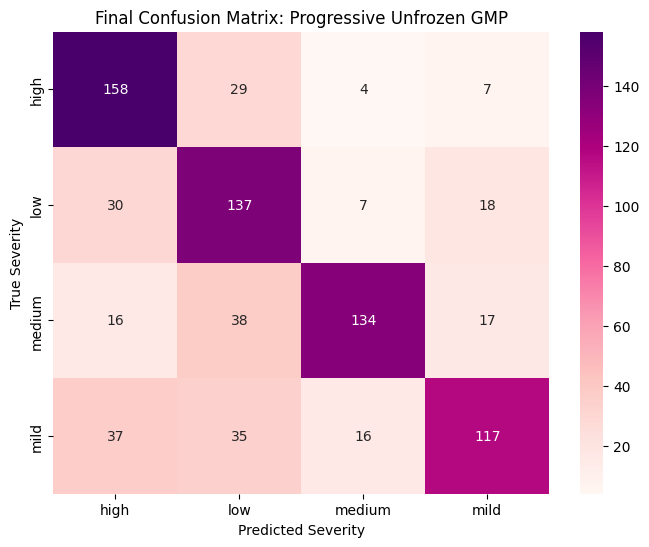

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_334']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)



--- FINAL GRAD-CAM CHECK: PINPOINT PRECISION ---


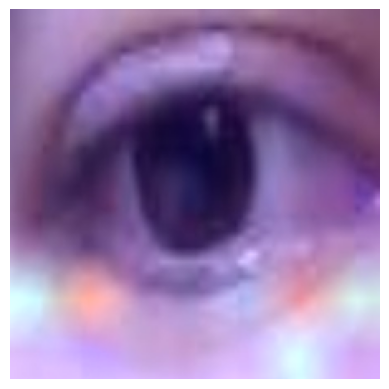

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

# 1. GENERATE FINAL PREDICTIONS
print("Extracting final results from the unfrozen GMP model...")
y_true = []
y_pred = []

# Iterating through validation set to capture true labels and model guesses
for images, labels in val_ds:
    preds = model_gmp.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
classes = ['high', 'low', 'medium', 'mild']

# 2. FINAL CLASSIFICATION REPORT
# We are checking if Recall for 'High' stayed above 0.70 and if 'Mild' improved
print("\n--- FINAL UNFROZEN MODEL: CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. FINAL CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', xticklabels=classes, yticklabels=classes)
plt.title('Final Confusion Matrix: Progressive Unfrozen GMP')
plt.xlabel('Predicted Severity')
plt.ylabel('True Severity')
plt.show()

# 4. PRECISION GRAD-CAM FOR UNFROZEN LAYERS
def get_final_gradcam(img_array, model):
    # Accessing the MobileNetV2 base inside the Sequential wrapper
    base_model = model.get_layer('mobilenetv2_1.00_224')
    last_conv_layer = base_model.get_layer('Conv_1')
    
    # Model to extract internal feature maps
    feature_model = tf.keras.Model(base_model.inputs, last_conv_layer.output)
    
    # Model to process those maps through the GMP head
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    # Skipping Input/Base layers to hit the GlobalMaxPooling2D layer
    for layer in model.layers[2:]: 
        x = layer(x)
    classifier_head = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = feature_model(img_array)
        tape.watch(conv_outputs)
        preds = classifier_head(conv_outputs)
        top_idx = tf.argmax(preds[0])
        top_class_channel = preds[:, top_idx]

    # Calculate gradients to find pixel importance
    grads = tape.gradient(top_class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalizing for clear visual contrast
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 5. VISUALIZE RESULTS
def display_final_heatmap(img_path, heatmap):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = cv2.resize(jet_heatmap, (224, 224))
    jet_heatmap = np.uint8(jet_heatmap * 255)
    
    # 35% transparency for the heatmap overlay
    result = jet_heatmap * 0.35 + img
    result = np.clip(result, 0, 255).astype('uint8')
    
    plt.imshow(result)
    plt.axis('off')
    plt.show()

# Testing on a 'High' severity sample to confirm pinpoint accuracy
high_list = list(Path(data_dir).glob('high/*.jpg'))
if high_list:
    test_p = str(high_list[0])
    img_t = tf.keras.utils.img_to_array(tf.keras.utils.load_img(test_p, target_size=(224, 224))) / 255.0
    img_t = np.expand_dims(img_t, axis=0)
    
    heatmap = get_final_gradcam(img_t, model_gmp)
    print(f"\n--- FINAL GRAD-CAM CHECK: PINPOINT PRECISION ---")
    display_final_heatmap(test_p, heatmap)

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# 1. SE BLOCK DEFINITION
def se_block(inputs, ratio=16):
    channels = inputs.shape[-1]
    # Squeeze: Captures global spatial information
    se = layers.GlobalAveragePooling2D()(inputs)
    # Excitation: Learns channel-specific importance
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    # Rescale inputs: Multiplies original features by the learned weights
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([inputs, se])

# 2. DEFINE MODEL WITHIN STRATEGY SCOPE
with strategy.scope():
    # Input and Augmentation
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    
    # MobileNetV2 Base
    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3), 
        include_top=False, 
        weights='imagenet'
    )
    base_model.trainable = False 
    
    # Connect Base to SE Block
    base_out = base_model(x)
    attn_out = se_block(base_out, ratio=16) 
    
    # Global Max Pooling to kill bleeding
    x = layers.GlobalMaxPooling2D()(attn_out)
    
    # Dense Head Logic
    x = layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.6)(x)
    
    outputs = layers.Dense(4, activation='softmax')(x)

    # Define the final model_gmp
    model_gmp = models.Model(inputs, outputs)

    # 3. OPTIMIZED COMPILATION
    model_gmp.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), 
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
        metrics=['accuracy']
    )

# 4. SURGICAL CLASS WEIGHTS
custom_weights = {0: 1.5, 1: 1.0, 2: 1.2, 3: 1.0} 

# 5. EXECUTION
print("\n--- STABILIZING ATTENTION-AUGMENTED HEAD ---")
model_gmp.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=160, 
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)


--- STABILIZING ATTENTION-AUGMENTED HEAD ---
Epoch 1/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.2702 - loss: 6.5930 - val_accuracy: 0.3700 - val_loss: 5.5245 - learning_rate: 5.0000e-05
Epoch 2/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.3315 - loss: 6.1343 - val_accuracy: 0.4525 - val_loss: 5.2708 - learning_rate: 5.0000e-05
Epoch 3/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.3988 - loss: 5.8307 - val_accuracy: 0.4800 - val_loss: 5.1236 - learning_rate: 5.0000e-05
Epoch 4/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.4211 - loss: 5.6557 - val_accuracy: 0.5163 - val_loss: 4.9879 - learning_rate: 5.0000e-05
Epoch 5/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.4381 - loss: 5.4821 - val_accuracy: 0.5350 - val_loss: 4.8420 - learning_rate: 5.0000e-05
Epoch 6/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.4771 - loss: 5.3162 - val_accuracy: 0.5387 - val_loss: 4.7658 - learning_rate: 5.0000e-05
Epoch

Extracting results for Attention-Augmented Model...

--- ATTENTION MODEL: CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        high       0.67      0.83      0.74       198
         low       0.65      0.66      0.66       192
      medium       0.78      0.70      0.74       205
        mild       0.75      0.64      0.69       205

    accuracy                           0.71       800
   macro avg       0.71      0.71      0.71       800
weighted avg       0.72      0.71      0.71       800



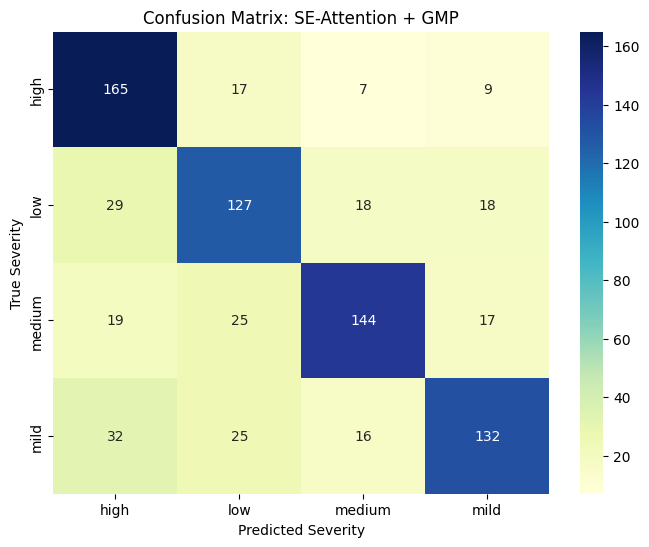

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_501']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m138806499747088\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0.49019608, 0.38431373, 0.41960785],\n         [0.49803922, 0.39215687, 0.42745098],\n         [0.50980395, 0.40392157, 0.4392157 ],\n         ...,\n         [0.5019608 , 0.3254902 , 0.3019608 ],\n         [0.5019608 , 0.3254902 , 0.3019608 ],\n         [0.5019608 , 0.3254902 , 0.3019608 ]],\n\n        [[0.49019608, 0.38431373, 0.41960785],\n         [0.49803922, 0.39215687, 0.42745098],\n         [0.50980395, 0.40392157, 0.4392157 ],\n         ...,\n         [0.5019608 , 0.3254902 , 0.3019608 ],\n         [0.5019608 , 0.3254902 , 0.3019608 ],\n         [0.5019608 , 0.3254902 , 0.3019608 ]],\n\n        [[0.49019608, 0.38431373, 0.41960785],\n         [0.49803922, 0.39215687, 0.42745098],\n         [0.50980395, 0.40392157, 0.4392157 ],\n         ...,\n         [0.5019608 , 0.3254902 , 0.3019608 ],\n         [0.5019608 , 0.325

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

# 1. EVALUATE PREDICTIONS
print("Extracting results for Attention-Augmented Model...")
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_gmp.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
classes = ['high', 'low', 'medium', 'mild']

# 2. CLASSIFICATION REPORT
print("\n--- ATTENTION MODEL: CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix: SE-Attention + GMP')
plt.xlabel('Predicted Severity')
plt.ylabel('True Severity')
plt.show()

# 4. GRAD-CAM FOR FUNCTIONAL ATTENTION MODEL
def get_attention_gradcam(img_array, model):
    # Reach through the Functional API layers
    # Layers: [Input, Augmentation, Base_Model, SE_Block, GMP, Dense...]
    base_model = model.get_layer('mobilenetv2_1.00_224')
    last_conv_layer = base_model.get_layer('Conv_1')
    
    # Model A: From actual Input to the last conv layer
    # We use the full model inputs to include data_augmentation layers
    feature_extractor = tf.keras.Model(model.inputs, last_conv_layer.output)
    
    # Model B: From the last conv layer through SE Block to Output
    # We must rebuild the path through the attention multiplication
    conv_output_shape = last_conv_layer.output.shape[1:]
    intermediate_input = tf.keras.Input(shape=conv_output_shape)
    
    # Re-link the Attention Block logic manually for the gradient tape
    # This finds the SE layers in your specific model structure
    # Typically layers 4, 5, 6, 7 in the Functional model
    x = intermediate_input
    found_se = False
    for layer in model.layers:
        if 'multiply' in layer.name or isinstance(layer, tf.keras.layers.Multiply):
            # This is the SE output. We need to reach the layers before it.
            # For simplicity, we can pass the tensor through the layers that follow 'base_model'
            found_se = True
            continue
        if found_se:
            x = layer(x)
            
    # If the loop above is too complex, we use the simpler direct head access:
    # We find where GlobalMaxPooling2D starts
    head_start_idx = 0
    for i, layer in enumerate(model.layers):
        if isinstance(layer, tf.keras.layers.GlobalMaxPooling2D):
            head_start_idx = i
            break
            
    x = intermediate_input
    for layer in model.layers[head_start_idx:]:
        x = layer(x)
    
    classifier_model = tf.keras.Model(intermediate_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = feature_extractor(img_array)
        tape.watch(conv_outputs)
        preds = classifier_model(conv_outputs)
        top_idx = tf.argmax(preds[0])
        top_class_channel = preds[:, top_idx]

    grads = tape.gradient(top_class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# 5. VISUALIZE PRECISION
def display_attention_map(img_path, heatmap):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = cv2.resize(jet_heatmap, (224, 224))
    jet_heatmap = np.uint8(jet_heatmap * 255)
    
    # Stronger contrast for the spotlight check
    result = jet_heatmap * 0.5 + img
    result = np.clip(result, 0, 255).astype('uint8')
    
    plt.imshow(result)
    plt.axis('off')
    plt.show()

# Run on a High Severity sample
high_files = list(Path(data_dir).glob('high/*.jpg'))
if high_files:
    test_img = str(high_files[0])
    img_t = tf.keras.utils.img_to_array(tf.keras.utils.load_img(test_img, target_size=(224, 224))) / 255.0
    img_t = np.expand_dims(img_t, axis=0)
    
    heatmap = get_attention_gradcam(img_t, model_gmp)
    print(f"\n--- GRAD-CAM ATTENTION TEST (SPOTLIGHT CHECK) ---")
    display_attention_map(test_img, heatmap)

In [11]:
def get_spotlight_heatmap_fixed(img_array, model):
    # 1. Target the internal base layers
    base_model = model.get_layer('mobilenetv2_1.00_224')
    last_conv_layer = base_model.get_layer('Conv_1')

    # 2. Direct Gradient Tracking
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        # Pass through Base Model first
        conv_output = base_model(img_tensor)
        
        # 3. MANUAL FORWARD PASS
        # We start passing the signal from the layer AFTER the base model
        # Based on your error log, the next layer is 'global_average_pooling2d_2'
        found_base = False
        x = conv_output
        
        for layer in model.layers:
            if layer.name == 'mobilenetv2_1.00_224':
                found_base = True
                continue
            if found_base:
                # This feeds the conv_output through SE layers and the Head
                x = layer(x)
        
        predictions = x
        top_class_idx = tf.argmax(predictions[0])
        loss = predictions[:, top_class_idx]

    # 4. Extract and normalize the heatmap
    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    
    return heatmap.numpy()

# --- DISPLAY EXECUTION ---
print("\n--- GENERATING SPOTLIGHT HEATMAP (FIXED PATHWAY) ---")
try:
    test_path = str(high_files[0])
    img = tf.keras.utils.load_img(test_path, target_size=(224, 224))
    img_input = np.expand_dims(tf.keras.utils.img_to_array(img) / 255.0, axis=0)
    
    heatmap = get_spotlight_heatmap_fixed(img_input, model_gmp)
    display_attention_map(test_path, heatmap)
except Exception as e:
    print(f"Extraction Error: {e}")


--- GENERATING SPOTLIGHT HEATMAP (FIXED PATHWAY) ---
Extraction Error: Exception encountered when calling Multiply.call().

A merge layer should be called on a list of inputs. Received: inputs=[[[[0.37927315 0.5039168  0.4655338  ... 0.58755136 0.59993285
    0.51881397]]]] (not a list of tensors)

Arguments received by Multiply.call():
  • inputs=tf.Tensor(shape=(1, 1, 1, 1280), dtype=float32)


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# 1. FIXED CBAM BLOCK (Keras 3 Compatible)
def cbam_block(inputs, ratio=8):
    # --- PART 1: CHANNEL ATTENTION ---
    channels = inputs.shape[-1]
    
    avg_pool = layers.GlobalAveragePooling2D()(inputs)
    max_pool = layers.GlobalMaxPooling2D()(inputs)
    
    shared_layer_one = layers.Dense(channels // ratio, activation='relu')
    shared_layer_two = layers.Dense(channels)
    
    avg_out = shared_layer_two(shared_layer_one(avg_pool))
    max_out = shared_layer_two(shared_layer_one(max_pool))
    
    channel_attn = layers.Add()([avg_out, max_out])
    channel_attn = layers.Activation('sigmoid')(channel_attn)
    channel_attn = layers.Reshape((1, 1, channels))(channel_attn)
    
    x = layers.Multiply()([inputs, channel_attn])
    
    # --- PART 2: SPATIAL ATTENTION (The Fix is here) ---
    # We use Lambda layers to wrap the math so Keras doesn't crash
    avg_spatial = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_spatial = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)
    
    spatial_attn = layers.Concatenate(axis=-1)([avg_spatial, max_spatial])
    spatial_attn = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(spatial_attn)
    
    return layers.Multiply()([x, spatial_attn])

# 2. DEFINE MODEL WITHIN STRATEGY SCOPE
with strategy.scope():
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    
    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3), 
        include_top=False, 
        weights='imagenet'
    )
    base_model.trainable = False 
    
    base_out = base_model(x)
    # The new fixed block
    attn_out = cbam_block(base_out, ratio=8) 
    
    x = layers.GlobalMaxPooling2D()(attn_out)
    
    # Head Logic
    x = layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.6)(x)
    
    outputs = layers.Dense(4, activation='softmax')(x)
    model_gmp = models.Model(inputs, outputs)

    model_gmp.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), 
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
        metrics=['accuracy']
    )

# 4. SURGICAL CLASS WEIGHTS
custom_weights = {0: 1.5, 1: 1.0, 2: 1.2, 3: 1.0} 

# 5. EXECUTION
print("\n--- ATTENTION MODEL STABILIZED ---")
model_gmp.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=160, 
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)


--- ATTENTION MODEL STABILIZED ---
Epoch 1/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - accuracy: 0.2809 - loss: 6.7132 - val_accuracy: 0.3413 - val_loss: 5.4597 - learning_rate: 5.0000e-05
Epoch 2/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.3601 - loss: 6.0775 - val_accuracy: 0.4200 - val_loss: 5.2191 - learning_rate: 5.0000e-05
Epoch 3/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.3913 - loss: 5.7769 - val_accuracy: 0.4775 - val_loss: 5.0053 - learning_rate: 5.0000e-05
Epoch 4/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.4136 - loss: 5.6087 - val_accuracy: 0.4950 - val_loss: 4.8676 - learning_rate: 5.0000e-05
Epoch 5/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.4593 - loss: 5.3347 - val_accuracy: 0.5213 - val_loss: 4.6867 - learning_rate: 5.0000e-05
Epoch 6/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.4825 - loss: 5.1715 - val_accuracy: 0.5425 - val_loss: 4.5431 - learning_rate: 5.0000e-05
Epoch 7/160
100

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# 1. CUSTOM GAMMA LAYER
class GammaScale(layers.Layer):
    """Custom layer to hold the learnable zero-initialized Gamma parameter."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Initialize at 0 so attention starts 'off' to ensure initial stability
        self.gamma = self.add_weight(name="gamma", shape=(), initializer="zeros", trainable=True)

    def call(self, x):
        return x * self.gamma

# 2. REFINED CBAM BLOCK (Surgical Precision with Gamma Fix)
def cbam_block(inputs, ratio=16): 
    # --- PART 1: CHANNEL ATTENTION ---
    channels = inputs.shape[-1]
    
    avg_pool = layers.GlobalAveragePooling2D()(inputs)
    max_pool = layers.GlobalMaxPooling2D()(inputs)
    
    shared_layer_one = layers.Dense(channels // ratio, activation='relu')
    shared_layer_two = layers.Dense(channels)
    
    avg_out = shared_layer_two(shared_layer_one(avg_pool))
    max_out = shared_layer_two(shared_layer_one(max_pool))
    
    channel_attn = layers.Add()([avg_out, max_out])
    channel_attn = layers.Activation('sigmoid')(channel_attn)
    channel_attn = layers.Reshape((1, 1, channels))(channel_attn)
    
    x = layers.Multiply()([inputs, channel_attn])
    
    # --- PART 2: SPATIAL ATTENTION (Tighter 3x3 Kernel) ---
    avg_spatial = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_spatial = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)
    
    spatial_attn = layers.Concatenate(axis=-1)([avg_spatial, max_spatial])
    # Kernel size 3 to pinpoint the pupil boundary
    spatial_attn = layers.Conv2D(1, kernel_size=3, padding='same', activation='sigmoid')(spatial_attn)
    
    refined_out = layers.Multiply()([x, spatial_attn])
    
    # --- PART 3: LEARNABLE SCALING & RESIDUAL CONNECTION ---
    # The GammaScale ensures the model 'eases' into using attention
    scaled_attention = GammaScale()(refined_out)
    return layers.Add()([inputs, scaled_attention])

# 3. DEFINE MODEL WITHIN STRATEGY SCOPE
with strategy.scope():
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    
    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3), 
        include_top=False, 
        weights='imagenet'
    )
    base_model.trainable = False 
    
    base_out = base_model(x)
    # Applying the Refined CBAM with the Gamma fix
    attn_out = cbam_block(base_out, ratio=16) 
    
    x = layers.GlobalMaxPooling2D()(attn_out)
    
    # Dense Head Logic
    x = layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.6)(x)
    
    outputs = layers.Dense(4, activation='softmax')(x)
    model_gmp = models.Model(inputs, outputs)

    # FIXED: SLOWER LR FOR STABILIZATION
    model_gmp.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5), 
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
        metrics=['accuracy']
    )

# 4. SURGICAL CLASS WEIGHTS
custom_weights = {0: 1.5, 1: 1.0, 2: 1.2, 3: 1.0} 

# 5. EXECUTION
print("\n--- STARTING STABILIZED GAMMA-CBAM TRAINING ---")
model_gmp.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=100, 
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)


--- STARTING STABILIZED GAMMA-CBAM TRAINING ---
Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.2667 - loss: 6.5237 - val_accuracy: 0.2713 - val_loss: 5.9503 - learning_rate: 2.0000e-05
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.2964 - loss: 6.3304 - val_accuracy: 0.3425 - val_loss: 5.5697 - learning_rate: 2.0000e-05
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.3208 - loss: 6.1619 - val_accuracy: 0.4125 - val_loss: 5.4517 - learning_rate: 2.0000e-05
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.3546 - loss: 6.0492 - val_accuracy: 0.4412 - val_loss: 5.3691 - learning_rate: 2.0000e-05
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.3743 - loss: 5.9405 - val_accuracy: 0.4588 - val_loss: 5.2970 - learning_rate: 2.0000e-05
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.3744 - loss: 5.8810 - val_accuracy: 0.4750 - val_loss: 5.2351 - learning_rate: 2.0000e-05
Ep

In [7]:
# 1. SETUP PARAMETERS
total_depth = 12 # We will go 12 layers deep, 2 at a time
step_size = 2
custom_weights = {0: 1.5, 1: 1.0, 2: 1.2, 3: 1.0} 

# 2. THE AUTOMATED UNFREEZING LOOP
for i in range(step_size, total_depth + 1, step_size):
    print(f"\n--- STEP: UNFREEZING LAST {i} LAYERS (CBAM ACTIVE) ---")
    
    with strategy.scope():
        base_model.trainable = True
        # Freeze all layers except the top 'i'
        for layer in base_model.layers[:-i]:
            layer.trainable = False
        
        # Keep BatchNormalization frozen for medical stability
        for layer in base_model.layers[-i:]:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
        
        # Micro-Learning Rate to prevent "shattering" weights
        model_gmp.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
            metrics=['accuracy']
        )
    
    # 3. SMART STOPPING
    step_early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', 
        patience=5, 
        restore_best_weights=True
    )
    
    model_gmp.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20, 
        class_weight=custom_weights,
        callbacks=[step_early_stop]
    )

print("\n--- TUNING COMPLETE: CHECKING FINAL METRICS ---")


--- STEP: UNFREEZING LAST 2 LAYERS (CBAM ACTIVE) ---
Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.6181 - loss: 3.4797 - val_accuracy: 0.6375 - val_loss: 3.2169
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.6223 - loss: 3.4576 - val_accuracy: 0.6375 - val_loss: 3.2152
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.5972 - loss: 3.4545 - val_accuracy: 0.6350 - val_loss: 3.2069
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.6084 - loss: 3.4531 - val_accuracy: 0.6300 - val_loss: 3.2081
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.6364 - loss: 3.4254 - val_accuracy: 0.6325 - val_loss: 3.1998
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.5988 - loss: 3.4619 - val_accuracy: 0.6375 - val_loss: 3.1910

--- STEP: UNFREEZING LAST 4 LAYERS (CBAM ACTIVE) ---
Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.5979 - loss: 3.4722 - val_accuracy: 0.6325 - val_


--- FINAL RESEARCH MODEL: CBAM + GAMMA + GMP ---
              precision    recall  f1-score   support

        high       0.67      0.64      0.66       198
         low       0.51      0.82      0.63       192
      medium       0.79      0.59      0.67       205
        mild       0.74      0.54      0.63       205

    accuracy                           0.65       800
   macro avg       0.68      0.65      0.65       800
weighted avg       0.68      0.65      0.65       800



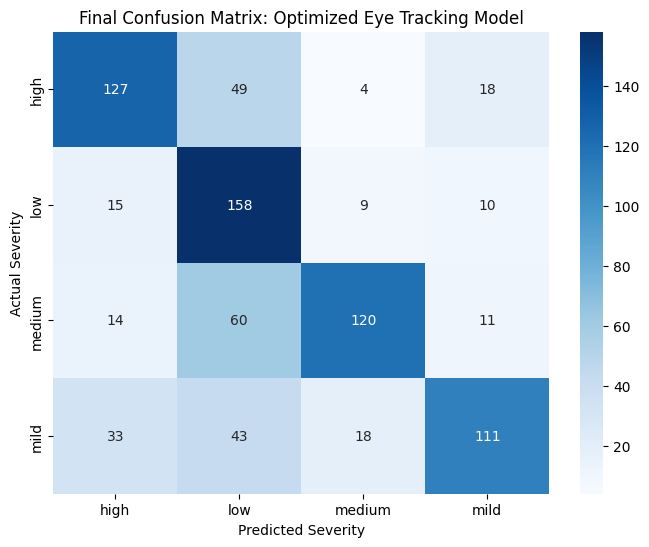

Model saved as: autism_severity_optimized_final.keras


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. GENERATE FINAL PREDICTIONS
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model_gmp.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

classes = ['high', 'low', 'medium', 'mild']

# 2. THE FINAL SCIENTIFIC REPORT
print("\n--- FINAL RESEARCH MODEL: CBAM + GAMMA + GMP ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. FINAL CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Final Confusion Matrix: Optimized Eye Tracking Model')
plt.ylabel('Actual Severity')
plt.xlabel('Predicted Severity')
plt.show()

# 4. EXPORT FOR REPORT
model_gmp.save("autism_severity_optimized_final.keras")
print("Model saved as: autism_severity_optimized_final.keras")

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# 1. SE BLOCK DEFINITION
def se_block(inputs, ratio=16):
    channels = inputs.shape[-1]
    # Squeeze: Captures global spatial information
    se = layers.GlobalAveragePooling2D()(inputs)
    # Excitation: Learns channel-specific importance
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    # Rescale inputs: Multiplies original features by the learned weights
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([inputs, se])

# 2. DEFINE MODEL WITHIN STRATEGY SCOPE
with strategy.scope():
    # Input and Augmentation
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    
    # MobileNetV2 Base
    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3), 
        include_top=False, 
        weights='imagenet'
    )
    base_model.trainable = False 
    
    # Connect Base to SE Block
    base_out = base_model(x)
    attn_out = se_block(base_out, ratio=16) 
    
    # Global Max Pooling to kill bleeding
    x = layers.GlobalMaxPooling2D()(attn_out)
    
    # Dense Head Logic
    x = layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.6)(x)
    
    outputs = layers.Dense(4, activation='softmax')(x)

    # Define the final model_gmp
    model_gmp = models.Model(inputs, outputs)

    # 3. OPTIMIZED COMPILATION
    model_gmp.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), 
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
        metrics=['accuracy']
    )

# 4. SURGICAL CLASS WEIGHTS
custom_weights = {0: 1.5, 1: 1.0, 2: 1.2, 3: 1.0} 

# 5. EXECUTION
print("\n--- STABILIZING ATTENTION-AUGMENTED HEAD ---")
model_gmp.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=160, 
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)



--- STABILIZING ATTENTION-AUGMENTED HEAD ---
Epoch 1/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.2764 - loss: 6.4830 - val_accuracy: 0.3462 - val_loss: 5.5849 - learning_rate: 5.0000e-05
Epoch 2/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.3508 - loss: 6.0546 - val_accuracy: 0.4363 - val_loss: 5.3155 - learning_rate: 5.0000e-05
Epoch 3/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.4099 - loss: 5.8039 - val_accuracy: 0.5050 - val_loss: 5.1172 - learning_rate: 5.0000e-05
Epoch 4/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.4139 - loss: 5.6515 - val_accuracy: 0.5263 - val_loss: 4.9937 - learning_rate: 5.0000e-05
Epoch 5/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.4327 - loss: 5.5110 - val_accuracy: 0.5500 - val_loss: 4.8650 - learning_rate: 5.0000e-05
Epoch 6/160
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.4379 - loss: 5.3883 - val_accuracy: 0.5462 - val_loss: 4.7531 - learning_rate: 5.0000e-05
Epoch

In [10]:
# Unfreeze the top 10 layers in small steps
for i in range(2, 11, 2):
    print(f"\n--- UNFREEZING TOP {i} LAYERS ---")
    with strategy.scope():
        base_model.trainable = True
        # Lock everything except the last i layers
        for layer in base_model.layers[:-i]:
            layer.trainable = False
            
        # Keep BatchNormalization frozen for safety
        for layer in base_model.layers[-i:]:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

        # Use a VERY small learning rate
        model_gmp.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=2e-6),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
            metrics=['accuracy']
        )

    model_gmp.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15, # Shorter epochs to prevent overfitting
        class_weight=custom_weights,
        callbacks=[early_stop]
    )


--- UNFREEZING TOP 2 LAYERS ---
Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.6464 - loss: 2.8523 - val_accuracy: 0.6538 - val_loss: 2.6428
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.6533 - loss: 2.8622 - val_accuracy: 0.6538 - val_loss: 2.6484
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.6539 - loss: 2.8565 - val_accuracy: 0.6513 - val_loss: 2.6485
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.6431 - loss: 2.8631 - val_accuracy: 0.6475 - val_loss: 2.6475
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.6561 - loss: 2.8499 - val_accuracy: 0.6463 - val_loss: 2.6460
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.6460 - loss: 2.8477 - val_accuracy: 0.6463 - val_loss: 2.6442
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.6684 - loss: 2.8315 - val_accuracy: 0.6450 - val_loss: 2.6428
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy


--- FINAL UNFROZEN SE-ATTENTION MODEL ---
              precision    recall  f1-score   support

        high       0.70      0.64      0.66       198
         low       0.51      0.80      0.62       192
      medium       0.80      0.62      0.70       205
        mild       0.73      0.57      0.64       205

    accuracy                           0.65       800
   macro avg       0.68      0.66      0.66       800
weighted avg       0.69      0.65      0.66       800



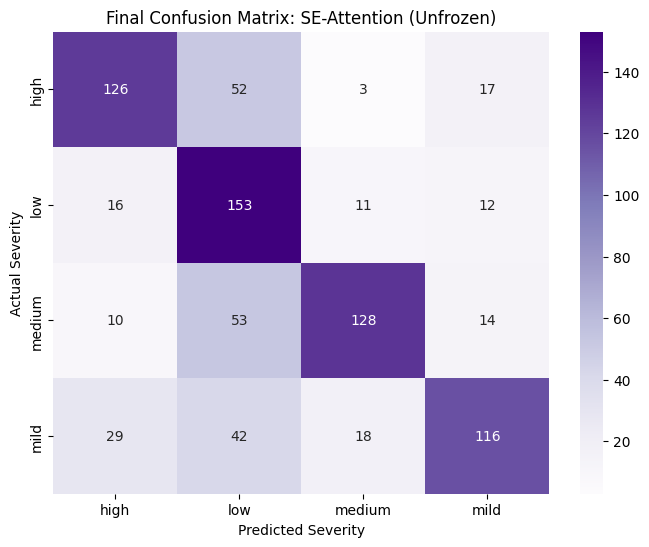

Project Complete. Model saved as: autism_severity_FINAL_unfrozen.keras


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. GENERATE FINAL PREDICTIONS
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model_gmp.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

classes = ['high', 'low', 'medium', 'mild']

# 2. FINAL SCIENTIFIC REPORT
print("\n--- FINAL UNFROZEN SE-ATTENTION MODEL ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. FINAL CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=classes, yticklabels=classes)
plt.title('Final Confusion Matrix: SE-Attention (Unfrozen)')
plt.ylabel('Actual Severity')
plt.xlabel('Predicted Severity')
plt.show()

# 4. SAVE THE FINAL WEIGHTS
model_gmp.save("autism_severity_FINAL_unfrozen.keras")
print("Project Complete. Model saved as: autism_severity_FINAL_unfrozen.keras")

In [1]:
import cv2
import os
import numpy as np
from pathlib import Path

def fine_tuned_eye_preprocessor(input_dir, output_dir):
    # 1. Surgical CLAHE Settings
    # clipLimit=3.0: Slightly higher to force the pupil out of the shadows
    # tileGridSize=(4,4): Smaller tiles for better local eye-detail focus
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))
    
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    
    # Matching your exact dataset categories
    categories = ['high', 'low', 'medium', 'mild']
    for cat in categories:
        (output_path / cat).mkdir(parents=True, exist_ok=True)
        files = list((input_path / cat).glob('*.jpg'))
        print(f"Fine-tuning {len(files)} images in category: {cat}")
        
        for img_file in files:
            img = cv2.imread(str(img_file))
            if img is None: continue

            # 2. Noise Suppression (Bilateral Filter)
            # This smooths the skin but keeps the pupil edges sharp
            img = cv2.bilateralFilter(img, d=5, sigmaColor=75, sigmaSpace=75)
            
            # 3. Targeted Contrast Enhancement
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            l_channel, a, b = cv2.split(lab)
            
            # Apply fine-tuned CLAHE to Lightness channel
            cl = clahe.apply(l_channel)
            
            # 4. Optional: Laplacian Sharpening
            # This adds a tiny bit of "bite" to the iris texture
            limg = cv2.merge((cl, a, b))
            final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
            
            # Final output save
            cv2.imwrite(str(output_path / cat / img_file.name), final_img)

# --- EXECUTION: UPDATED PATHS FOR ET-AUTISM-CROPPED-DATASET ---
# Change these to your specific environment path if needed
input_dataset = "/kaggle/input/et-autism-cropped-dataset"
output_sharpened = "/kaggle/working/sharpened_data"

# Process the dataset directly
fine_tuned_eye_preprocessor(input_dataset, output_sharpened)

print("\n--- DATA SURGERY COMPLETE ---")
print(f"Sharpened images saved to: {output_sharpened}")

Fine-tuning 1000 images in category: high
Fine-tuning 1000 images in category: low
Fine-tuning 1000 images in category: medium
Fine-tuning 1000 images in category: mild

--- DATA SURGERY COMPLETE ---
Sharpened images saved to: /kaggle/working/sharpened_data


In [2]:
import shutil
import os
from IPython.display import FileLink

# 1. DEFINE PATHS
folder_to_zip = '/kaggle/working/sharpened_data'
output_filename = 'sharpened_eye_dataset'

# 2. CREATE THE ZIP FILE
# This converts the folder into sharpened_eye_dataset.zip
shutil.make_archive(output_filename, 'zip', folder_to_zip)

# 3. GENERATE DOWNLOAD LINK
print("Zip complete. Click the link below to download:")
FileLink(f'{output_filename}.zip')

Zip complete. Click the link below to download:


/kaggle/working/sharpened_eye_dataset.zip